In [ ]:
import torch
from datasets import load_from_disk
from accelerate import init_empty_weights, load_checkpoint_and_dispatch
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from transformers.utils import SAFE_WEIGHTS_INDEX_NAME, SAFE_WEIGHTS_NAME, hub
import safetensors.torch

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fastcore.all import *

In [ ]:
import sys
sys.path.append("../../scripts")

In [ ]:
from dataset_utils import get_dataloader

### Original Model Loss

In [ ]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-32B-Instruct", device_map="auto", torch_dtype=torch.bfloat16)

Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████| 17/17 [00:17<00:00,  1.05s/it]


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-32B-Instruct")

In [ ]:
args = {}
args["dataset"] = "/home/k/data/qwen_large_mix_dataset_v0_dedup_1024"
args["seed"] = 42
args["batch_size"] = 4
args["gradient_accumulation_steps"] = 8
args["context_length"] = 1024

dataloader = get_dataloader(tokenizer, args, pad_to_nearest=False, debug=True)

In [ ]:
b = next(iter(dataloader))

In [ ]:
ds = load_from_disk("/home/k/data/qwen_large_mix_dataset_v0_dedup_1024")

In [ ]:
b

{'input_ids': tensor([[151644,   8948,    198,  ..., 151643, 151643, 151643],
         [151644,   8948,    198,  ..., 151643, 151643, 151643],
         [151644,   8948,    198,  ...,  57087,     13, 151645],
         [151644,   8948,    198,  ..., 151643, 151643, 151643]]),
 'attention_mask': None,
 'labels': tensor([[  -100,   -100,   -100,  ...,   -100,   -100,   -100],
         [  -100,   -100,   -100,  ...,   -100,   -100,   -100],
         [  -100,   -100,   -100,  ...,  57087,     13, 151645],
         [  -100,   -100,   -100,  ...,   -100,   -100,   -100]])}

In [ ]:
losses = []
step_loss, bs = 0, 0
for b in dataloader:
    with torch.inference_mode():
        output = model(b['input_ids'], labels=b['labels'],attention_mask=None)
        loss = output.loss

    step_loss += loss.item() * args['batch_size']
    bs        += args['batch_size'] 
        
    if bs % 32 == 0:
        iter_loss = step_loss / bs
        losses.append(iter_loss)
        step_loss, bs = 0, 0
        print(iter_loss)
    
    if len(losses) >= 30: break

In [ ]:
%ai reset

In [ ]:
%%aip 0 
Add horizontal line to plot as mean of losses

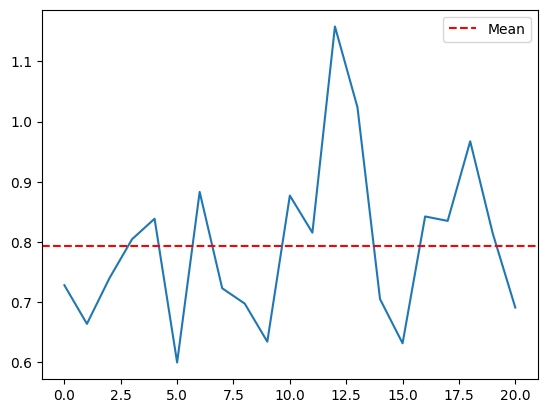

In [ ]:
plt.plot(losses)
plt.axhline(y=np.mean(losses), color='r', linestyle='--', label='Mean')
plt.legend()
plt.show()

### Gradual Unfreeze

In [ ]:
qwen_2_5_32b_scores = sorted_scores = [(0, 0.88851666),
 (63, 0.50742525),
 (62, 0.080078125),
 (4, 0.074041955),
 (3, 0.06959692),
 (5, 0.059793405),
 (8, 0.05809705),
 (61, 0.052911166),
 (7, 0.049501617),
 (2, 0.04781368),
 (9, 0.044181034),
 (32, 0.043701172),
 (6, 0.043621194),
 (49, 0.04266568),
 (50, 0.041205045),
 (51, 0.040691506),
 (60, 0.040262155),
 (34, 0.039601292),
 (46, 0.03936978),
 (31, 0.039272968),
 (47, 0.03905408),
 (48, 0.038902547),
 (33, 0.038708918),
 (1, 0.03854896),
 (52, 0.03843952),
 (30, 0.03831745),
 (44, 0.03763554),
 (35, 0.036355905),
 (53, 0.03627593),
 (10, 0.036065463),
 (45, 0.03559402),
 (36, 0.034987878),
 (28, 0.0344575),
 (15, 0.03378401),
 (14, 0.033687197),
 (43, 0.033514615),
 (29, 0.033485148),
 (12, 0.033177868),
 (59, 0.033022124),
 (54, 0.032580145),
 (27, 0.032466494),
 (13, 0.032403354),
 (16, 0.0319277),
 (11, 0.031784583),
 (55, 0.031603582),
 (37, 0.03145205),
 (56, 0.030955348),
 (26, 0.030677533),
 (17, 0.030265018),
 (18, 0.030084018),
 (22, 0.03000825),
 (20, 0.029982995),
 (19, 0.029856715),
 (38, 0.029852506),
 (39, 0.029587317),
 (42, 0.029435782),
 (21, 0.029183224),
 (57, 0.028922245),
 (23, 0.02888857),
 (58, 0.028349778),
 (40, 0.027419519),
 (41, 0.026804958),
 (25, 0.026316676),
 (24, 0.026093582)]

In [ ]:
layer_scores_dict = dict(qwen_2_5_32b_scores)

In [ ]:
# CLA(2) adjacent - layer_idx : kv_cache_idx
CLA2_ADJ={0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 10, 12: 10, 13: 10, 14: 10, 15: 10, 16: 10, 17: 10, 18: 10, 19: 10, 20: 10, 21: 10, 22: 10, 23: 10, 24: 10, 25: 10, 26: 10, 27: 10, 28: 10, 29: 10, 30: 11, 31: 12, 32: 13, 33: 14, 34: 15, 35: 16, 36: 17, 37: 17, 38: 17, 39: 17, 40: 17, 41: 17, 42: 17, 43: 17, 44: 18, 45: 19, 46: 20, 47: 21, 48: 22, 49: 23, 50: 24, 51: 25, 52: 26, 53: 27, 54: 27, 55: 27, 56: 27, 57: 27, 58: 27, 59: 27, 60: 28, 61: 29, 62: 30, 63: 31}

# CLA(2) no adjacent - layer_idx : kv_cache_idx
CLA2_NO_ADJ={0: 0, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 4, 7: 5, 8: 6, 9: 6, 10: 7, 11: 7, 12: 8, 13: 8, 14: 8, 15: 9, 16: 9, 17: 10, 18: 10, 19: 10, 20: 11, 21: 11, 22: 12, 23: 12, 24: 12, 25: 12, 26: 13, 27: 13, 28: 14, 29: 14, 30: 15, 31: 15, 32: 16, 33: 16, 34: 17, 35: 17, 36: 18, 37: 18, 38: 19, 39: 19, 40: 19, 41: 19, 42: 20, 43: 20, 44: 21, 45: 21, 46: 22, 47: 22, 48: 22, 49: 23, 50: 23, 51: 24, 52: 24, 53: 25, 54: 25, 55: 26, 56: 26, 57: 27, 58: 27, 59: 28, 60: 28, 61: 29, 62: 30, 63: 31}

# CLA(3) adjacent - layer_idx : kv_cache_idx
CLA3_ADJ={0: 0, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 8, 11: 8, 12: 8, 13: 8, 14: 8, 15: 8, 16: 8, 17: 8, 18: 8, 19: 8, 20: 8, 21: 8, 22: 8, 23: 8, 24: 8, 25: 8, 26: 8, 27: 8, 28: 8, 29: 8, 30: 8, 31: 9, 32: 10, 33: 10, 34: 11, 35: 11, 36: 11, 37: 11, 38: 11, 39: 11, 40: 11, 41: 11, 42: 11, 43: 11, 44: 11, 45: 11, 46: 12, 47: 13, 48: 13, 49: 14, 50: 15, 51: 16, 52: 16, 53: 16, 54: 16, 55: 16, 56: 16, 57: 16, 58: 16, 59: 16, 60: 17, 61: 18, 62: 19, 63: 20}

# CLA(3) no adjacent - layer_idx : kv_cache_idx
CLA3_NO_ADJ={0: 0, 1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 4, 7: 5, 8: 6, 9: 6, 10: 7, 11: 7, 12: 7, 13: 7, 14: 7, 15: 7, 16: 7, 17: 7, 18: 7, 19: 7, 20: 7, 21: 7, 22: 7, 23: 7, 24: 7, 25: 7, 26: 7, 27: 7, 28: 8, 29: 8, 30: 9, 31: 9, 32: 10, 33: 10, 34: 11, 35: 11, 36: 12, 37: 12, 38: 12, 39: 12, 40: 12, 41: 12, 42: 12, 43: 12, 44: 13, 45: 13, 46: 14, 47: 14, 48: 14, 49: 15, 50: 15, 51: 16, 52: 16, 53: 17, 54: 17, 55: 17, 56: 17, 57: 17, 58: 17, 59: 17, 60: 17, 61: 18, 62: 19, 63: 20}

In [ ]:
def create_compute_new_kv_map(cla_kv_cache_map) -> dict[int, bool]:
    "Returns a dict of decoder layer idxs and whether KV needs to be computed at that layer to be cached."
    if cla_kv_cache_map is None: return {}
    comput_new_kv_map = {}
    is_seen = set()
    for k,v in cla_kv_cache_map.items():
        if v not in is_seen:
            comput_new_kv_map[k] = True
            is_seen.add(v)
        else:
            comput_new_kv_map[k] = False
    return comput_new_kv_map

In [ ]:
compute_new_kv_map = create_compute_new_kv_map(CLA2_ADJ); compute_new_kv_map

{0: True,
 1: True,
 2: True,
 3: True,
 4: True,
 5: True,
 6: True,
 7: True,
 8: True,
 9: True,
 10: True,
 11: False,
 12: False,
 13: False,
 14: False,
 15: False,
 16: False,
 17: False,
 18: False,
 19: False,
 20: False,
 21: False,
 22: False,
 23: False,
 24: False,
 25: False,
 26: False,
 27: False,
 28: False,
 29: False,
 30: True,
 31: True,
 32: True,
 33: True,
 34: True,
 35: True,
 36: True,
 37: False,
 38: False,
 39: False,
 40: False,
 41: False,
 42: False,
 43: False,
 44: True,
 45: True,
 46: True,
 47: True,
 48: True,
 49: True,
 50: True,
 51: True,
 52: True,
 53: True,
 54: False,
 55: False,
 56: False,
 57: False,
 58: False,
 59: False,
 60: True,
 61: True,
 62: True,
 63: True}

In [ ]:
# sort layers that re-use KV by score and unfreeze starting from the least important layers first
trainable_layers_scores = {lidx:layer_scores_dict[lidx] for lidx,new_kv in compute_new_kv_map.items() if not new_kv}
trainable_layers_scores = sorted(list(trainable_layers_scores.items()), key=lambda x: x[1])

In [ ]:
trainable_layers_scores[:5], len(trainable_layers_scores)

([(24, 0.026093582),
  (25, 0.026316676),
  (41, 0.026804958),
  (40, 0.027419519),
  (58, 0.028349778)],
 32)

In [ ]:
%%aip 0
Write a function which will take a dictionary like full_cla_kv_cache_map. Starting from key=0 it will check previous value and update the current value if necessary so that if value is equal to the previous or if the value is -1 it will remain as is, otherwise it should be previous value + 1.

In [ ]:
def update_map_values(d):
    d = d.copy()
    remap_dict = {}
    prev = -1
    for k in sorted(d.keys()):
        if d[k] == -1: 
            continue
            
        if k == 0: 
            prev = d[k]
            continue
            
        if d[k] in remap_dict:
            d[k] = remap_dict[d[k]]
            
        elif d[k] != prev and d[k] != prev+1:
            remap_dict[d[k]] = prev + 1
            d[k] = prev + 1
            
        prev = d[k]
    return d

In [ ]:
test_dict = {0:0, 
             1:1, 
             2:-1, 
             3:3, 
             4:-1, 
             5:4,
             6:-1,
             7:-1,
             8:7,
             9:7}
expected_test_dict = {0:0, 
                     1:1, 
                     2:-1, 
                     3:2, 
                     4:-1, 
                     5:3,
                     6:-1,
                     7:-1,
                     8:4,
                     9:4}

In [ ]:
assert update_map_values(test_dict) == expected_test_dict

In [ ]:
sorted_lidxs = [i[0] for i in trainable_layers_scores]
trainable_idxs_set = set(sorted_lidxs)

In [ ]:
steps = 300
num_stages = 8
steps_per_stage = steps / num_stages; steps_per_stage

37.5

In [ ]:
stage_cla_kv_cache_maps = []
stage_train_idxs = []
for train_idxs in chunked(sorted_lidxs, n_chunks=num_stages):
    
    # update idxs to train in the stage.
    stage_train_idxs.extend(train_idxs)
    remaining_idxs = trainable_idxs_set.difference(stage_train_idxs)
    
    # set trainable skipped layers as -1 and remap values.
    full_cla_kv_cache_map = CLA2_ADJ.copy()
    for lidx in remaining_idxs:
        full_cla_kv_cache_map[lidx] = -1
    partial_cla_kv_cache_map = update_map_values(full_cla_kv_cache_map)
    stage_cla_kv_cache_maps.append(partial_cla_kv_cache_map)

In [ ]:
assert partial_cla_kv_cache_map == full_cla_kv_cache_map

In [ ]:
print("\n".join([f"CLA2_ADJ_STAGE_{i}='{str(s)}'" for i,s in enumerate(stage_cla_kv_cache_maps)]))

CLA2_ADJ_STAGE_0='{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: -1, 12: -1, 13: -1, 14: -1, 15: -1, 16: -1, 17: -1, 18: -1, 19: -1, 20: -1, 21: -1, 22: -1, 23: -1, 24: 10, 25: 10, 26: -1, 27: -1, 28: -1, 29: -1, 30: 11, 31: 12, 32: 13, 33: 14, 34: 15, 35: 16, 36: 17, 37: -1, 38: -1, 39: -1, 40: 17, 41: 17, 42: -1, 43: -1, 44: 18, 45: 19, 46: 20, 47: 21, 48: 22, 49: 23, 50: 24, 51: 25, 52: 26, 53: 27, 54: -1, 55: -1, 56: -1, 57: -1, 58: -1, 59: -1, 60: 28, 61: 29, 62: 30, 63: 31}'
CLA2_ADJ_STAGE_1='{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: -1, 12: -1, 13: -1, 14: -1, 15: -1, 16: -1, 17: -1, 18: -1, 19: -1, 20: -1, 21: 10, 22: -1, 23: 10, 24: 10, 25: 10, 26: -1, 27: -1, 28: -1, 29: -1, 30: 11, 31: 12, 32: 13, 33: 14, 34: 15, 35: 16, 36: 17, 37: -1, 38: -1, 39: -1, 40: 17, 41: 17, 42: -1, 43: -1, 44: 18, 45: 19, 46: 20, 47: 21, 48: 22, 49: 23, 50: 24, 51: 25, 52: 26, 53: 27, 54: -1, 55: -1, 56: -1, 57: 27, 58: 27, 59: -1, 60: 28, 6

In [ ]:
# TODO: if a layer is used once and doesn't share its kv set it as -1.

In [ ]:
model_name = "Qwen/Qwen2.5-32B-Instruct"
idx = hub.cached_file(model_name, SAFE_WEIGHTS_INDEX_NAME)
files, _ = hub.get_checkpoint_shard_files(model_name, idx)

In [ ]:
files[0]

'/home/k/.cache/huggingface_copy/hub/models--Qwen--Qwen2.5-32B-Instruct/snapshots/5ede1c97bbab6ce5cda5812749b4c0bdf79b18dd/model-00001-of-00017.safetensors'

In [ ]:
orig_weights = {**safetensors.torch.load_file(files[0]), **safetensors.torch.load_file(files[1])}

In [ ]:
# CLA_DEBUG_STAGE_0='{0:0, 1:-1, 2:1, 3:1}'
weights_step5 = safetensors.torch.load_file("/home/k/models/qwen_cla_fp8kv_debug/step_5/model_state_dict.safetensors")
# CLA_DEBUG_STAGE_1='{0:0, 1:-1, 2:1, 3:1}'
weights_step10 = safetensors.torch.load_file("/home/k/models/qwen_cla_fp8kv_debug/step_10/model_state_dict.safetensors")

In [ ]:
updated,not_updated,unseen = [],[],[] 
for n,p in weights_step5.items():
    if n in orig_weights:
        if not torch.equal(orig_weights[n],p):
            updated.append(n)
        else:
            not_updated.append(n)
    else: unseen.append(n)
updated,not_updated,unseen

(['model.layers.3.input_layernorm.weight',
  'model.layers.3.mlp.down_proj.weight',
  'model.layers.3.mlp.gate_proj.weight',
  'model.layers.3.mlp.up_proj.weight',
  'model.layers.3.post_attention_layernorm.weight',
  'model.layers.3.self_attn.o_proj.weight',
  'model.layers.3.self_attn.q_proj.bias',
  'model.layers.3.self_attn.q_proj.weight'],
 ['model.embed_tokens.weight',
  'model.layers.0.input_layernorm.weight',
  'model.layers.0.mlp.down_proj.weight',
  'model.layers.0.mlp.gate_proj.weight',
  'model.layers.0.mlp.up_proj.weight',
  'model.layers.0.post_attention_layernorm.weight',
  'model.layers.0.self_attn.k_proj.bias',
  'model.layers.0.self_attn.k_proj.weight',
  'model.layers.0.self_attn.o_proj.weight',
  'model.layers.0.self_attn.q_proj.bias',
  'model.layers.0.self_attn.q_proj.weight',
  'model.layers.0.self_attn.v_proj.bias',
  'model.layers.0.self_attn.v_proj.weight',
  'model.layers.1.input_layernorm.weight',
  'model.layers.1.mlp.down_proj.weight',
  'model.layers.1.ml

In [ ]:
updated,not_updated,unseen = [],[],[] 
for n,p in weights_step10.items():
    if n in orig_weights:
        if not torch.equal(orig_weights[n],p):
            updated.append(n)
        else:
            not_updated.append(n)
    else: unseen.append(n)
updated,not_updated,unseen

(['model.layers.1.input_layernorm.weight',
  'model.layers.1.mlp.down_proj.weight',
  'model.layers.1.mlp.gate_proj.weight',
  'model.layers.1.mlp.up_proj.weight',
  'model.layers.1.post_attention_layernorm.weight',
  'model.layers.1.self_attn.o_proj.weight',
  'model.layers.1.self_attn.q_proj.bias',
  'model.layers.1.self_attn.q_proj.weight',
  'model.layers.3.input_layernorm.weight',
  'model.layers.3.mlp.down_proj.weight',
  'model.layers.3.mlp.gate_proj.weight',
  'model.layers.3.mlp.up_proj.weight',
  'model.layers.3.post_attention_layernorm.weight',
  'model.layers.3.self_attn.o_proj.weight',
  'model.layers.3.self_attn.q_proj.bias',
  'model.layers.3.self_attn.q_proj.weight'],
 ['model.embed_tokens.weight',
  'model.layers.0.input_layernorm.weight',
  'model.layers.0.mlp.down_proj.weight',
  'model.layers.0.mlp.gate_proj.weight',
  'model.layers.0.mlp.up_proj.weight',
  'model.layers.0.post_attention_layernorm.weight',
  'model.layers.0.self_attn.k_proj.bias',
  'model.layers.0.

### Save Model Weights

In [ ]:
from transformers.utils import SAFE_WEIGHTS_INDEX_NAME, SAFE_WEIGHTS_NAME, hub
import safetensors.torch
from pathlib import Path
import os, json

In [ ]:
os.environ['HF_HOME']

'/workspace/.cache/huggingface'

In [ ]:
models_dir = Path("/workspace/models/")

In [ ]:
list(models_dir.glob("qwen*"))

[Path('/workspace/models/qwen_cla_fp8kv_cla2_no_adj'),
 Path('/workspace/models/qwen_cla_fp8kv_cla2_adj_gradual_unfreeze'),
 Path('/workspace/models/qwen_cla_fp8kv_cla2_adj')]

In [ ]:
weights['model.layers.0.self_attn.v_scale']

tensor([0.1001], dtype=torch.bfloat16)

In [ ]:
def shard_saved_model_weights(model_weigths_file, save_dir):

    model_name = "Qwen/Qwen2.5-32B-Instruct"
    idx = hub.cached_file(model_name, SAFE_WEIGHTS_INDEX_NAME)
    files, _ = hub.get_checkpoint_shard_files(model_name, idx)
    
    weights = safetensors.torch.load_file(model_weigths_file)
    save_dir = Path(save_dir)
    save_dir.mkdir(exist_ok=True)
    safetensors_idx_dict = json.load(open(idx))

    for fn in files:
        orig_weights = safetensors.torch.load_file(fn)
        assert not set(orig_weights.keys()).difference(weights.keys())

        shard_state_dict = {}
        # copy all shard weights
        for k in orig_weights:
            shard_state_dict[k] = weights[k]

        # copy all extra weights of the shard layers: such as k_scale and v_scale
        xtra_layers = set(".".join(n.split(".")[:3])+".self_attn" for n in shard_state_dict if "layers" in n)
        for l in xtra_layers:
            for k in [l+".k_scale", l+".v_scale"]:
                shard_state_dict[k] = weights[k]

        # save the shard state dict
        shard_name = Path(fn).name
        safetensors.torch.save_file(shard_state_dict, save_dir/shard_name, metadata={"format": "pt"})

        # add new weights to idx
        for k,v in shard_state_dict.items():
            if "_scale" in k: 
                print(k,v)
                safetensors_idx_dict['weight_map'][k] = shard_name

    # save idx file
    with open(save_dir/Path(idx).name, "w") as fp:
        json.dump(safetensors_idx_dict, fp)

In [ ]:
# config_dict = json.load(open(Path(files[0]).parent/'config.json'))

In [ ]:
model_weigths_file = "/workspace/models/qwen_cla_fp8kv_cla2_no_adj/step_300/model_state_dict.safetensors"
save_dir = "/workspace/models/qwen_cla_fp8kv_cla2_no_adj/step_300_hf"

shard_saved_model_weights(model_weigths_file, save_dir)

model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.v_scale tensor([0.1001], dtype=torch.bf

model.layers.49.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.49.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], 

In [ ]:
model_weigths_file = "/workspace/models/qwen_cla_fp8kv_cla2_adj/step_300/model_state_dict.safetensors"
save_dir = "/workspace/models/qwen_cla_fp8kv_cla2_adj/step_300_hf"

shard_saved_model_weights(model_weigths_file, save_dir)

model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.v_scale tensor([0.1001], dtype=torch.bf

model.layers.49.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.49.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], 

In [ ]:
model_weigths_file = "/workspace/models/qwen_cla_fp8kv_cla2_adj_gradual_unfreeze/step_280/model_state_dict.safetensors"
save_dir = "/workspace/models/qwen_cla_fp8kv_cla2_adj_gradual_unfreeze/step_280_hf"

shard_saved_model_weights(model_weigths_file, save_dir)

model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.0.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.1.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.3.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.2.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.6.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.4.self_attn.v_scale tensor([0.1001], dtype=torch.bf

model.layers.49.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.49.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.48.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.46.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.47.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.54.self_attn.v_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.k_scale tensor([0.1001], dtype=torch.bfloat16)
model.layers.50.self_attn.v_scale tensor([0.1001], 